In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Shape:", df.shape)
df.info()
df.describe(include="all").T

Shape: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [3]:
df = df.copy()

for col in ["sex", "smoker", "region"]:
    df[col] = df[col].str.strip().str.lower()

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
df.to_csv("insurance_cleaned.csv", index=False)

df.shape

Missing values: 0
Duplicate rows: 1


(1337, 7)

In [4]:
df.groupby("smoker")["charges"].agg(["count", "mean", "median"]).round(2)

,count,mean,median
smoker,,,
no,1063,8440.66,7345.73
yes,274,32050.23,34456.35


In [5]:
encoded = pd.get_dummies(df, drop_first=True, dtype=int)

correlation = (
    encoded.corr(numeric_only=True)["charges"]
    .drop("charges")
    .sort_values(key=abs, ascending=False)
)

correlation.to_frame("Correlation with Charges")

,Correlation with Charges
smoker_yes,0.787234
age,0.298308
bmi,0.198401
region_southeast,0.073578
children,0.067389
sex_male,0.058044
region_southwest,-0.043637
region_northwest,-0.038695


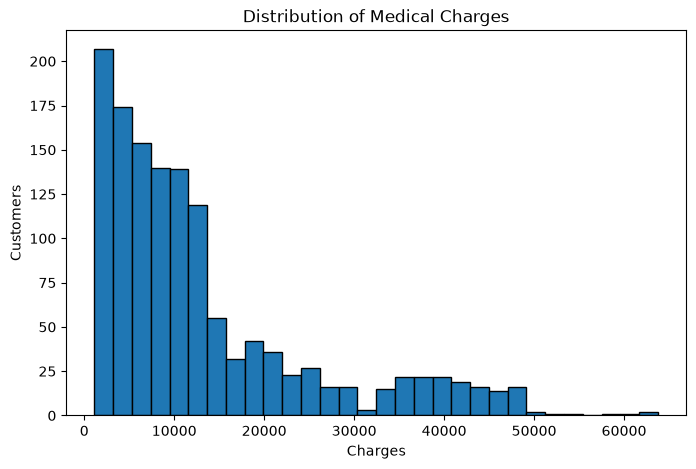

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30, edgecolor="black")
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Customers")
plt.show()

<Figure size 800x500 with 0 Axes>

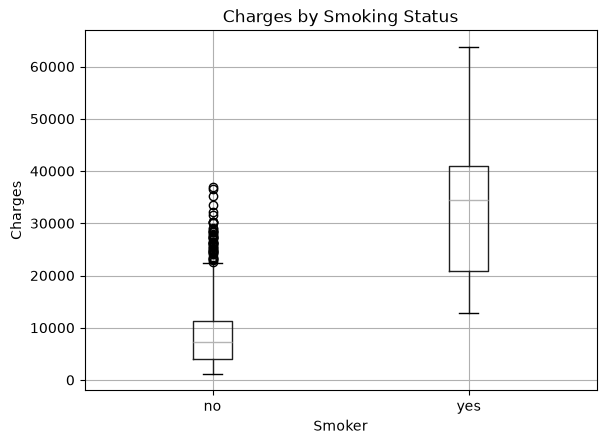

In [7]:
plt.figure(figsize=(8, 5))
df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

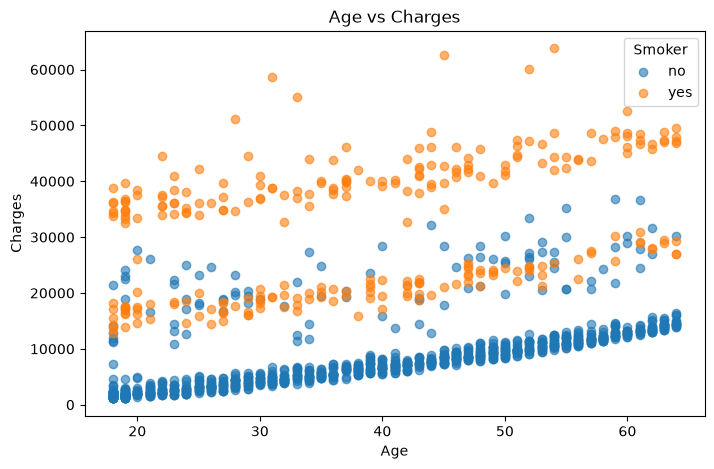

In [8]:
plt.figure(figsize=(8, 5))

for status, group in df.groupby("smoker"):
    plt.scatter(group["age"], group["charges"], alpha=0.6, label=status)

plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(title="Smoker")
plt.show()

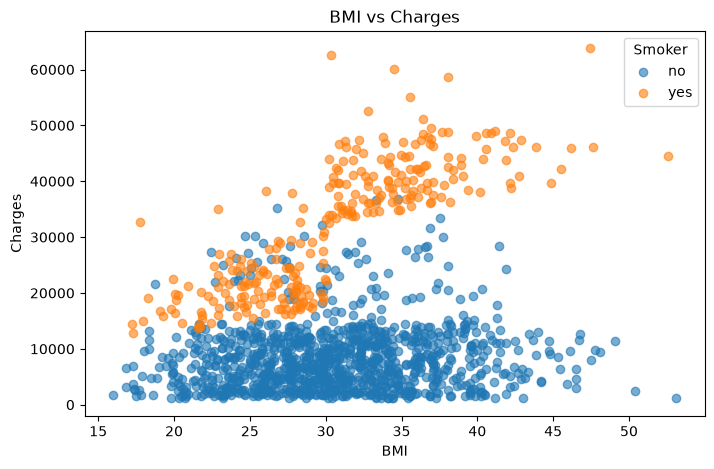

In [9]:
plt.figure(figsize=(8, 5))

for status, group in df.groupby("smoker"):
    plt.scatter(group["bmi"], group["charges"], alpha=0.6, label=status)

plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend(title="Smoker")
plt.show()

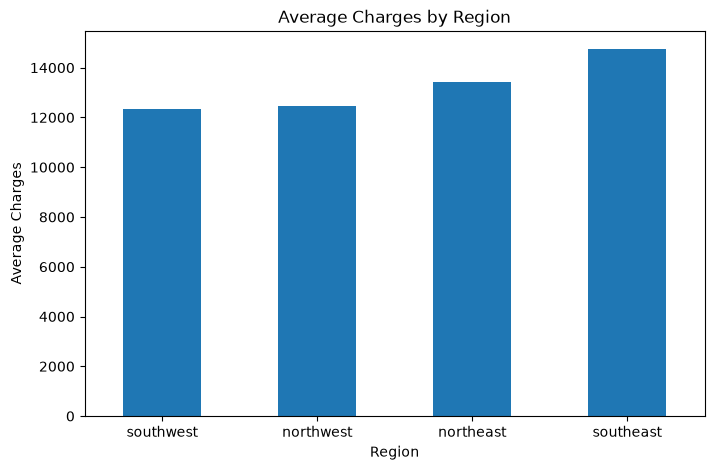

In [10]:
region_mean = df.groupby("region")["charges"].mean().sort_values()

plt.figure(figsize=(8, 5))
region_mean.plot(kind="bar")
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.xticks(rotation=0)
plt.show()

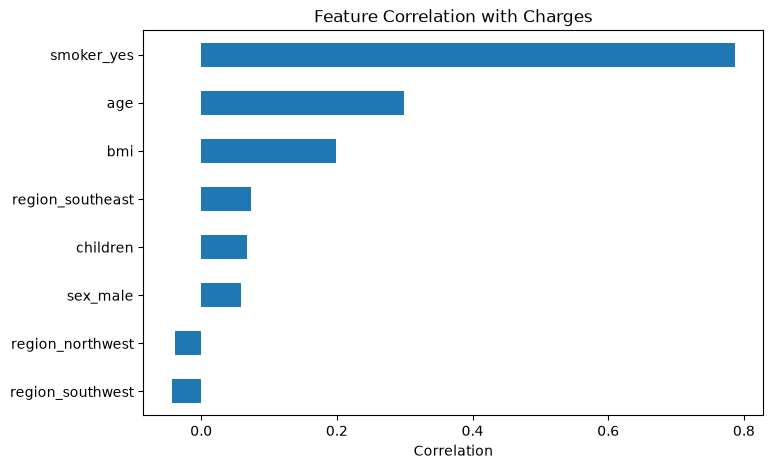

In [11]:
plt.figure(figsize=(8, 5))
correlation.sort_values().plot(kind="barh")
plt.title("Feature Correlation with Charges")
plt.xlabel("Correlation")
plt.show()